In [1]:
# %cd turnus
%load_ext autoreload
%autoreload 2

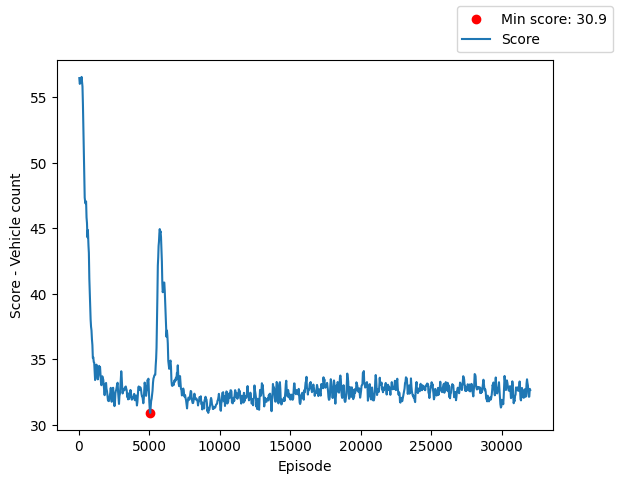

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

training = '241223#4dep_100trips'
df = pd.read_csv(f'results/{training}/score.csv')
df2 = pd.read_csv(f'results/{training}/loss.csv')
fig, ax1 = plt.subplots()

best_score, index = np.min(df['avg_score']), np.argmin(df['avg_score'])

ax1.scatter(df['episode'][index], best_score, c='red', label=f"Min score: {round(best_score, 1)}")
ax1.plot(df['episode'], df['avg_score'], label='Score')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Score - Vehicle count')

# ax1.axhline(y=4, color='r', linestyle='--', label='Target score')
# ax1.text(0, 4.5, 'Target score', color='red', fontsize=8)

# ax2 = ax1.twinx()
# ax2.plot(df2['iteration'], df2['ext_value'], c='green', label='Extrinsic value loss')
# ax2.plot(df2['episode'], df2['int_value'], c='orange', label='Intrinsic value loss')
fig.legend()

In [41]:
import time
from typing import List
import torch
from utils.problem_loader import ProblemLoader
from env import Env
import utils.graph_utils as graph_utils
from torch_geometric.data import Data
from model import HybridNetwork
import torch.nn.functional as F
import matplotlib.pyplot as plt

def e_greedy_eval(net: torch.nn.Module, env: Env):
    observation, mask = env.reset()
    terminal = False
    l = False
    r_sum = 0
    while not terminal:
        net.zero_grad()
        observation.x.requires_grad_(True)
        logit, _, _ = net(observation)
        logit.max().backward()
        grad = observation.x.grad

        # if l == False:
        #     l = True
        #     plt.plot(list(range(logit.shape[1])), logit[0].cpu().detach())

        logit = torch.where(mask, logit, torch.tensor(-1e+8, device=logit.device))
        probs = F.softmax(logit, dim=-1)
        action = probs.argmax()
        # print(action.item(), end=" ")
        observation, mask, reward, terminal, _ = env.step(action.item())
        r_sum += reward

    transform_rewards = env.reward_to_score_transformer()

    return observation, r_sum, env.vehicleID - 1

def search_results(net: torch.nn.Module, env: Env, search_count = 100):
    result_observations = []
    result_rewards = []
    for i in range(search_count):
        observation, mask = env.reset()
        terminal = False

        r_sum = 0
        while not terminal:
            logit, ext_value, int_value = net(observation)
            logit = torch.where(mask, logit, torch.tensor(-1e+8, device=device))
            probs = F.softmax(logit, dim = -1)
            action = probs.multinomial(num_samples = 1)
            observation, mask, reward, terminal, _ = env.step(action.item())
            r_sum += reward

        result_observations.append(observation)
        result_rewards.append(r_sum)

    transform_rewards = env.reward_to_score_transformer()

    return result_observations, result_rewards, list(map(transform_rewards, result_rewards))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

nodes = []
times = []
net = None
loader = ProblemLoader('data/8dep_1500trips/')
for problem in range(1, 6):
    graph, optimal = loader.load(f'RN-8-1500-0{problem}')
    env = Env(graph = graph, device=device)

    if net is None:
        net = HybridNetwork(env.state_space(), env.action_space()).to(device)
        print(f'Creating new model')
        net.load_state_dict(torch.load(f'results/{training}/models/iter_{160}.pt', map_location=device))
    else:
        net.node_count = env.action_space()
    net.eval()

    start = time.time()
    observation, _, vehicles = e_greedy_eval(net, env)
    # observations, rewards, vehicles = search_results(net, env, 100)
    took = round(time.time() - start, 2)

    times.append(took)
    nodes.append(graph.num_nodes)
    print(f'Problem {problem} ({graph.num_nodes} nodes); \t optimal: {optimal} \t agent: {vehicles} ({vehicles/optimal:2f}) - it took {took}s')

Creating new model


KeyboardInterrupt: 

In [40]:
import time
from typing import List
import torch
from utils.problem_loader import ProblemLoader
from env import Env
from torch_geometric.data import Data, Batch
from model import HybridNetwork
import torch.nn.functional as F

def e_paralel_greedy_eval(net: torch.nn.Module, envs: List[Env]):
    observations, masks = zip(*[env.reset() for env in envs])
    masks = torch.stack(masks)
    observations = Batch.from_data_list(observations).to(device)
    terminals = np.zeros(len(envs), dtype=bool)
    while not terminals.all():
        logits, _, _ = net(observations)

        logits = torch.where(masks, logits, torch.tensor(-1e+8, device=logits.device))
        probs = F.softmax(logits, dim=-1)
        actions = probs.argmax(dim = -1)

        new_observations = []
        masks = []
        indices = np.where(~terminals)[0]
        for i, env_i in enumerate(indices):
            env = envs[env_i]
            observation, mask, _, terminal, _ = env.step(actions[i].item())
            terminals[env_i] = terminal
            
            if not terminal:
                new_observations.append(observation)
                masks.append(mask)

        if len(new_observations) > 0:
            observations = Batch.from_data_list(new_observations).to(device)
            masks = torch.stack(masks)

    return observations, None, [env.vehicleID - 1 for env in envs]

loader = ProblemLoader('data/8dep_1500trips/')

envs = []
optimals = []
for problem in range(1, 6):
    graph, optimal = loader.load(f'RN-8-1500-0{problem}')
    env = Env(graph = graph, device=device)

    envs.append(env)
    optimals.append(optimal)

net = HybridNetwork(env.state_space(), env.action_space()).to(device)
net.load_state_dict(torch.load(f'results/{training}/models/iter_{160}.pt', map_location=device))

start = time.time()
observations, _, vehicles = e_paralel_greedy_eval(net, envs)
took = round(time.time() - start, 2)

for i in range(len(envs)):
    vehicle = vehicles[i]
    optimal = optimals[i]
    print(f'Problem {i+1} ({envs[i].graph.num_nodes} nodes); \t optimal: {optimal} \t agent: {vehicle} ({vehicle/optimal if optimal != None else 0:2f})')

print(f'Paralel took {took}s')

Problem 1 (1516 nodes); 	 optimal: 372 	 agent: 379 (1.018817)
Problem 2 (1516 nodes); 	 optimal: 342 	 agent: 346 (1.011696)
Problem 3 (1516 nodes); 	 optimal: 369 	 agent: 373 (1.010840)
Problem 4 (1516 nodes); 	 optimal: 354 	 agent: 355 (1.002825)
Problem 5 (1516 nodes); 	 optimal: 343 	 agent: 347 (1.011662)
Paralel took 42.57s


In [6]:
import os

def get_models(path):
    files = {}
    for file in os.listdir(path):
        if file.endswith('.pt'):
            iteration = int(file.split('_')[-1].split('.')[0])
            files[iteration] = file

    keys = sorted(files.keys())
    i_keys = [ keys[0] ]
    for i in range(1, len(keys)):
        key = keys[i]
        if key - i_keys[-1] > 20:
            i_keys.append(key)

    return i_keys, [ files[i] for i in i_keys ]

problems = list(range(1, 10)) + [ 'martin', 10 ]
models = get_models('results/240315#p_rand_110_dmodel/models')
for problem in problems:
    graph, optimal = graph_utils.load_problem(f'data/{problem}')

    env = Env(graph = graph, optimal = optimal, device=device)
    net = GCNPolicy(env.state_space(), env.action_space()).to(device)
    env.reset()

    for iteration, file in models:
        net.load_state_dict(torch.load(f'results/240315#p_rand_110_dmodel/models/{file}', map_location=device))
        net.eval()

        observation, _, vehicles = e_greedy_eval(net, env)
        nodes.append(graph.num_nodes)
        print(f'Problem {problem} ({graph.num_nodes} nodes); model {file}; \t agent: {vehicles} (opt. {optimal}) - it took {took}s')

['iter_0.pt',
 'iter_21.pt',
 'iter_42.pt',
 'iter_63.pt',
 'iter_163.pt',
 'iter_736.pt',
 'iter_812.pt',
 'iter_1000.pt',
 'iter_1723.pt',
 'iter_2000.pt',
 'iter_2648.pt',
 'iter_3000.pt',
 'iter_4000.pt',
 'iter_5000.pt',
 'iter_6000.pt',
 'iter_7000.pt',
 'iter_8000.pt']

Text(0.5, 1.0, 'Time to solve problems of different sizes')

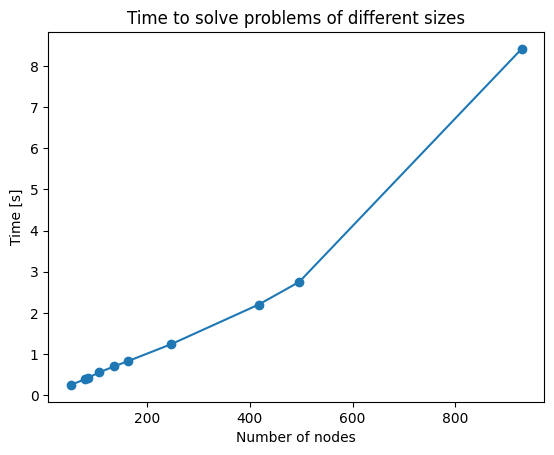

In [19]:
import matplotlib.pyplot as plt

plt.scatter(nodes, times)
plt.plot(nodes, times)
plt.xlabel('Number of nodes')
plt.ylabel('Time [s]')
plt.title('Time to solve problems of different sizes')

In [10]:
o = observation.cpu()

o.x

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.5000, 0.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.6667, 0.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.1667, 0.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.3333, 0.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000]])

In [43]:
def get_tours_by_vehicles(graph: Data, env: Env):
    vehicles = {}
    for i in range(graph.num_nodes):
        node = graph.x[i]
        vehicle = (node[env.flag_visited_index] * env.MAX_VEHICLES).round(decimals=4).item()

        if vehicle != int(vehicle):
            raise ValueError(f"Vehicle ID is not an integer. Got {vehicle} for {i}")

        vehicle = int(vehicle)

        if str(vehicle) not in vehicles:
            vehicles[str(vehicle)] = []

        vehicles[str(vehicle)].append(i)

    return vehicles

get_tours_by_vehicles(observation.cpu(), env)

{'0': [0, 78],
 '65': [1],
 '67': [2],
 '64': [3],
 '63': [4],
 '66': [5],
 '62': [6],
 '61': [7],
 '60': [8],
 '58': [9],
 '59': [10],
 '56': [11],
 '57': [12],
 '54': [13],
 '55': [14],
 '53': [15],
 '52': [16],
 '51': [17],
 '50': [18],
 '49': [19],
 '47': [20],
 '48': [21],
 '45': [22],
 '44': [23],
 '46': [24],
 '42': [25],
 '41': [26],
 '43': [27],
 '20': [28],
 '24': [29],
 '27': [30],
 '29': [31],
 '30': [32],
 '33': [33],
 '35': [34],
 '36': [35],
 '39': [36],
 '40': [37],
 '37': [38],
 '38': [39],
 '31': [40],
 '34': [41],
 '32': [42],
 '28': [43],
 '25': [44],
 '21': [45],
 '22': [46],
 '26': [47],
 '23': [48],
 '19': [49],
 '18': [50],
 '15': [51],
 '16': [52],
 '14': [53],
 '17': [54],
 '13': [55],
 '12': [56],
 '10': [57, 59],
 '11': [58],
 '8': [60],
 '9': [61],
 '7': [62],
 '6': [63],
 '5': [64],
 '3': [65],
 '4': [66],
 '2': [67],
 '1': [68, 69, 70, 71, 72, 73, 74, 75, 76, 77]}

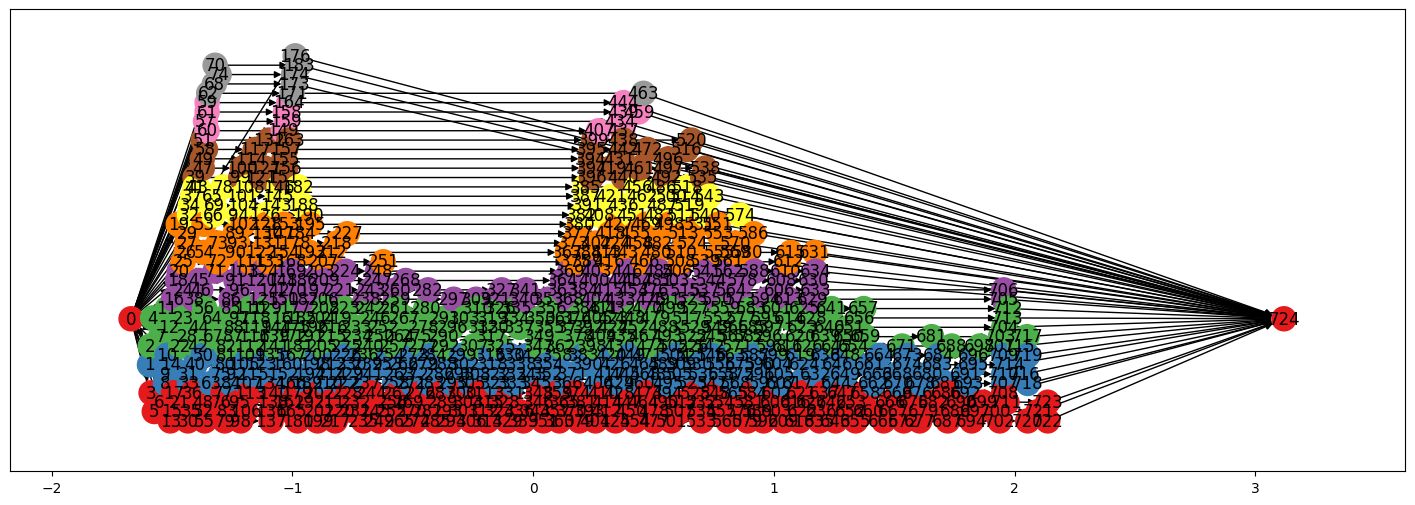

In [48]:
import networkx as nx
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import numpy as np

def get_result_subgraph(graph: Data, env: Env):
    vehicle_tours = get_tours_by_vehicles(graph, env)
    start_depo, end_depo = vehicle_tours['0']
    edges = []
    for vehicle, node_ids in vehicle_tours.items():
        if vehicle == '0':
            continue
        
        if len(node_ids) > 0:
            edges.append([start_depo, node_ids[0]])

        for i in range(len(node_ids) - 1):
            edges.append([node_ids[i], node_ids[i+1]])

        if len(node_ids) > 0:
            edges.append([node_ids[-1], end_depo])

    edges = torch.tensor(edges)

    return Data(x=graph.x, edge_index=edges.t().contiguous())

def draw_graph_by_vehicles(graph: Data, env: Env):
    node_labels = graph.x[:, env.flag_visited_index].numpy()
    positions = {}

    center = np.mean(node_labels)

    for i in range(graph.num_nodes):
        node = graph.x[i]
        if node[env.flag_visited_index] == 0:
            positions[i] = [node[2], center]
        else:
            positions[i] = [node[2], node[env.flag_visited_index]]

    g = to_networkx(graph)

    fig, ax = plt.subplots(1, 1, figsize=(18,6))
    nx.draw(g, pos=positions, cmap=plt.get_cmap('Set1'), node_color=node_labels, with_labels=True, ax=ax)
    limits=plt.axis('on')
    ax.tick_params(left=False, bottom=True, labelleft=False, labelbottom=True)

# observation, _, vehicles = e_greedy_eval(net, env)
draw_graph_by_vehicles(get_result_subgraph(observation.cpu(), env), env)